In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyscf import gto, scf

In [35]:
mol = gto.M(
    atom='H 0 0 0; H 0 0 1',  # Hydrogen molecule, atoms 1 angstrom apart
    basis='6-31g'                # The LCAO basis set
)

# 2. Create the SCF object (Mean-field)
mf = scf.RHF(mol)
mf.kernel()

converged SCF energy = -1.09480796286051


np.float64(-1.0948079628605125)

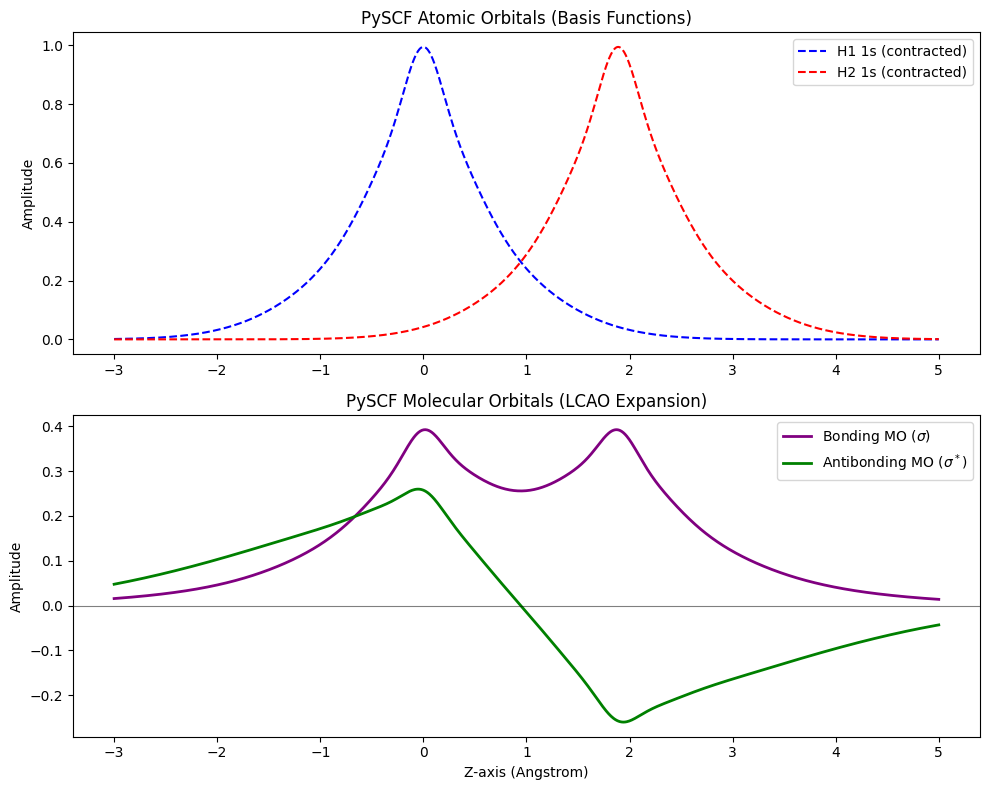

In [33]:
z = np.linspace(-3, 5, 1000)
points = np.zeros((1000, 3))
points[:, 2] = z

# Get the Atomic Orbitals
ao_values = mol.eval_gto("GTOval", points)

# Get the Molecular Orbitals
mo_values = np.dot(ao_values, mf.mo_coeff)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(z, ao_values[:, 0], label='H1 1s (contracted)', color='blue', linestyle='--')
ax1.plot(z, ao_values[:, 2], label='H2 1s (contracted)', color='red', linestyle='--')
ax1.set_title("PySCF Atomic Orbitals (Basis Functions)")
ax1.set_ylabel("Amplitude")
ax1.legend()

ax2.plot(z, mo_values[:, 0], label=r'Bonding MO ($\sigma$)', color='purple', linewidth=2)
ax2.plot(z, mo_values[:, 1], label=r'Antibonding MO ($\sigma^*$)', color='green', linewidth=2)
ax2.axhline(0, color='black', lw=0.8, alpha=0.5)
ax2.set_title("PySCF Molecular Orbitals (LCAO Expansion)")
ax2.set_xlabel("Z-axis (Angstrom)")
ax2.set_ylabel("Amplitude")
ax2.legend()

plt.tight_layout()
plt.show()